In [20]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import scipy.ndimage as ndimage

In [21]:
weights_path = "final_weights.npy"
test_image_path = "test2.jpg" # Use an image NOT in the 59 training set
map_types = ["human", "eye", "box"]

n_features = 256
target_size = (227, 227)

In [22]:
# --- 1. Load Data ---
print(f"Loading final weights from {weights_path}...")
# final_weights.npy contains a dictionary
loaded_weights = np.load(weights_path, allow_pickle=True).item()
print("Loading and preprocessing test image...")
if not os.path.exists(test_image_path):
    print(f"Error: Test image not found at {test_image_path}")
    exit()

# Load original image for plotting
original_img = mpimg.imread(test_image_path)
original_h, original_w, _ = original_img.shape

Loading final weights from final_weights.npy...
Loading and preprocessing test image...


In [23]:
# --- 2. Extract Features  ---
print(f"Extracting AlexNet Conv5 features from test image...")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image

device = torch.device("cpu")
alexnet = models.alexnet(weights='IMAGENET1K_V1').to(device).eval()
features_extractor = nn.Sequential(*list(alexnet.features)[:12])

def extract_and_resize_features(img_path):
    """
    Extract Conv5+ReLU features and interpolate to 227x227 using CPU
    """
    preprocess = transforms.Compose([
        transforms.Resize((227, 227)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    img = Image.open(img_path).convert('RGB')
    input_tensor = preprocess(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        # Feature shape: [1, 256, 13, 13]
        raw_features = features_extractor(input_tensor)
        
        # Interpolate to match input resolution 227x227
        interpolated = F.interpolate(raw_features, size=(227, 227), mode='bilinear', align_corners=False)
        
    return interpolated.squeeze(0).numpy() # (256, 227, 227)

# features shape: (256, 227, 227)
features = extract_and_resize_features(test_image_path)
features_flat = features.reshape(n_features, -1).T # shape (51529, 256)

# Dictionary to store the 3 prediction maps
predicted_maps = {}

Extracting AlexNet Conv5 features from test image...


In [25]:
# --- 3. Generate Prediction Maps  ---
print(f"Generating saliency maps using 256 weights...")

for m_type in map_types:
    print(f"  Predicting for: {m_type}")
    weights = loaded_weights[m_type] # (256,)
    
    # Simple linear combination: Map = Features @ Weights
    # Result is (51529,)
    pred_flat = features_flat @ weights
    
    # Reshape back to spatial dimensions
    pred_map = pred_flat.reshape(target_size)
    
    # --- Post-processing for Visualization ---
    # A. Gaussian Smoothing (Sigma=5 pixels is common for saliency)
    pred_smooth = ndimage.gaussian_filter(pred_map, sigma=5)
    
    # B. Min-Max Normalization to [0, 1] for Heatmap
    p_min = np.min(pred_smooth)
    p_max = np.max(pred_smooth)
    # Avoid division by zero if map is blank
    if p_max > p_min:
        pred_norm = (pred_smooth - p_min) / (p_max - p_min)
    else:
        pred_norm = np.zeros(target_size)
        
    # C. Resize back to original image size for blending
    # (Using ndimage.zoom is faster than other resizing methods for this)
    zoom_factors = (original_h / target_size[0], original_w / target_size[1])
    pred_final = ndimage.zoom(pred_norm, zoom_factors, order=1) # Bilinear
    
    predicted_maps[m_type] = pred_final

Generating saliency maps using 256 weights...
  Predicting for: human
  Predicting for: eye
  Predicting for: box


Creating 2x2 comparison plot...

--- Saliency Prediction Complete ---


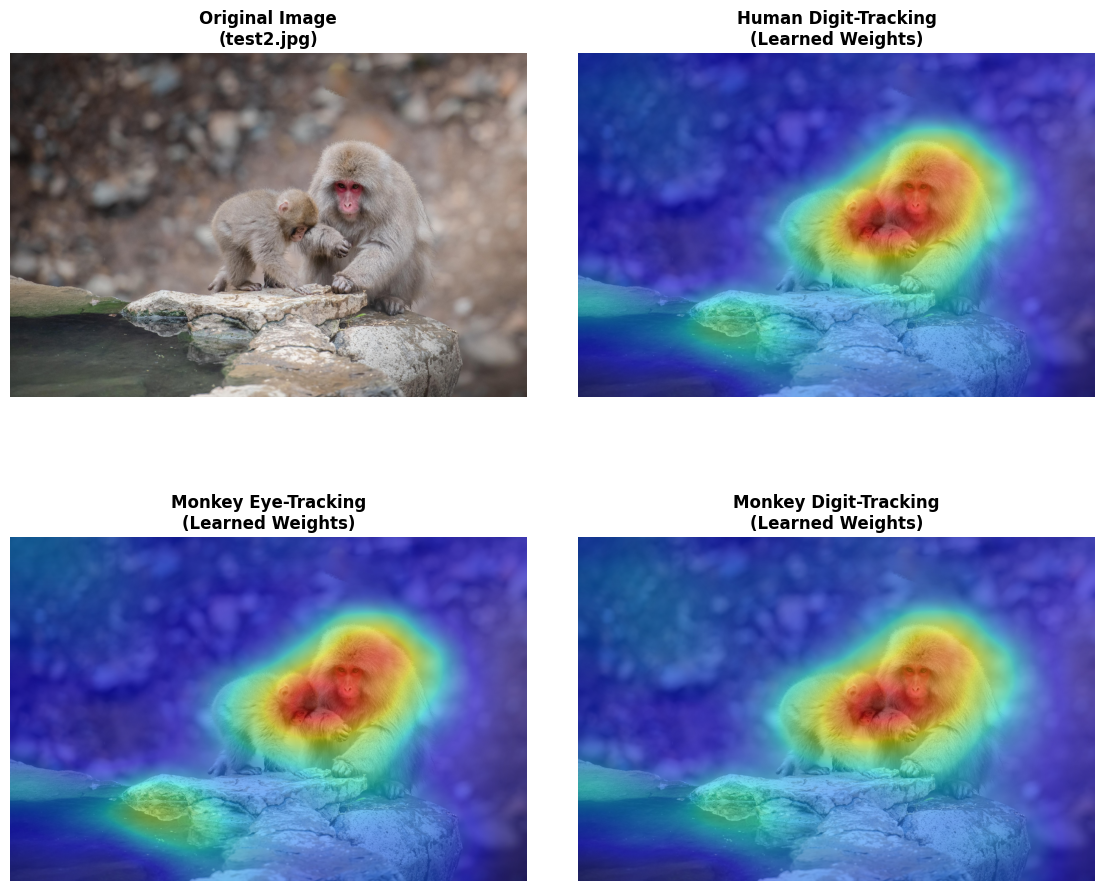

In [26]:
# --- 4. 2x2 Visualization ---
print("Creating 2x2 comparison plot...")
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plt.subplots_adjust(wspace=0.1, hspace=0.1)

# Plot titles matching your descriptions
titles = [
    f"Original Image\n({test_image_path})",
    f"Human Digit-Tracking\n(Learned Weights)",
    f"Monkey Eye-Tracking\n(Learned Weights)",
    f"Monkey Digit-Tracking\n(Learned Weights)"
]

flat_axes = axes.flatten()

# Iteration setup: (Map Type, Axis Index)
# None is used for the Original image (no heatmap)
plot_setup = [(None, 0), ('human', 1), ('eye', 2), ('box', 3)]

for i, (m_type, ax_idx) in enumerate(plot_setup):
    ax = flat_axes[ax_idx]
    ax.imshow(original_img)
    ax.set_title(titles[i], fontsize=12, fontweight='bold')
    ax.axis('off')
    
    # If it's a prediction, superimpose the heatmap
    if m_type is not None:
        ax.imshow(predicted_maps[m_type], cmap='jet', alpha=0.5) # Jet is standard for saliency

print("\n--- Saliency Prediction Complete ---")
plt.show()